# **0. LIBRERÍAS Y CONFIGURACIÓN**

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.impute import KNNImputer

# Preprocesamiento y Modelado
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.preprocessing import TargetEncoder
# modelos

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# Métricas
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **1. Carga de datos procesados y exploración inicial**

In [2]:
df = pd.read_parquet("../data/processed/dataset.parquet")

# El parquet ya viene con el filtro de precio aplicado desde el EDA.
# Aquí reforzamos solo el filtro de áreas para evitar outliers extremos.
df_filtrado = df[
    (df["Área Construida (m2)"] <= 2500) &
    (df["Área Privada (m2)"] <= 2500)
].copy()

print(df_filtrado["Área Construida (m2)"].max())
print(df_filtrado["Área Privada (m2)"].max())

2416.0
2416.0


# **Feature engineering**

# **Split de datos (train/test)**

### Separación de variables predictoras (X) y variable objetivo (y, "Precio")

### <span style="color: #dc2626;">!!! **Importante: comentarios para recordar**</span>


1. voy a usar Barrio_group como parte de las features, pero la idea es que luego podamos definir realmente cuales van a ser las variables que vamos a usar despues de que toda la limpieza y análisis haya terminado, estoy usando el que hace que vaya a "otros"
2. también estoy usando piso_cat
3. pareciera que para poder usar optuna, es mejor hacer algo como train, test y validation porque optuna corremos el riesgo de ajustar el modelo al test indirectamente, la idea es que  Optuna compare configuraciones sin “mirar” el test final, y eso es algo que no hicimos en el trabajo de la profe camila

70% train: el modelo aprende
15% validation : Optuna prueba distintas combinaciones y decide cuáles son mejores
15% test: una sola vez al final para medir el desempeño real

4. tenemos que definir que métrica nos importa mas para nuestros modelos entre MAE, RMSE y R2
5. tampoco podemos incluir area privada m2 porque hace multicolinealidad


In [3]:
df_filtrado.columns

Index(['ID', 'Barrio', 'Tipo de Inmueble', 'Estado', 'Antigüedad',
       'Área Construida (m2)', 'Área Privada (m2)', 'Estrato', 'Baños',
       'Habitaciones', 'Parqueaderos', 'Piso N°', 'URL', 'Precio',
       'Barrio_clean', 'Barrio_group', 'Piso_cat'],
      dtype='object')

In [4]:

numeric_features = [
    "Área Construida (m2)",
    "Estrato",
    "Baños",
    "Habitaciones",
    "Parqueaderos",
]

categorical_features = [
    "Tipo de Inmueble",
    "Estado",
    "Antigüedad",
    "Barrio_group",
    "Piso_cat",
]

features = numeric_features + categorical_features



In [5]:
# En el EDA vimos que estas son las variables que tienen valores faltantes, por lo que las vamos a imputar con KNN Imputer.

cols_int   = ["Baños", "Habitaciones"]
cols_float = ["Área Construida (m2)"]
cols_all   = cols_int + cols_float

# Separación de variables predictoras (X) y variable objetivo (y, "Precio")

X = df_filtrado[features].copy()
y = df_filtrado["Precio"].copy()

# SPlit antes de imputar con knn las variables que nos hacen falta y 70% train, 30% temporal test

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
)  

# Del 30% temporal, mitad validation y mitad test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

# Guardamos una copia para revisar el antes y el despues de baños
X_train_before = X_train.copy()
mask_banos_train = X_train_before["Baños"].isna()

# KNN fit solo en train
imputer_knn = KNNImputer(n_neighbors=5)
imputer_knn.fit(X_train[cols_all])

# Transform por separado
X_train.loc[:, cols_all] = imputer_knn.transform(X_train[cols_all])
X_val.loc[:, cols_all]   = imputer_knn.transform(X_val[cols_all])
X_test.loc[:, cols_all]  = imputer_knn.transform(X_test[cols_all])

# Redondear enteros
X_train[cols_int] = X_train[cols_int].round(0).astype(int)
X_val[cols_int]   = X_val[cols_int].round(0).astype(int)
X_test[cols_int]  = X_test[cols_int].round(0).astype(int)

# Revisamos como quedaron los registros cuyo valor de Baños estaba vacío
comparacion_banos = pd.DataFrame({
    "Tipo de Inmueble": X_train_before.loc[mask_banos_train, "Tipo de Inmueble"],
    "Area_antes": X_train_before.loc[mask_banos_train, "Área Construida (m2)"],
    "Habitaciones_antes": X_train_before.loc[mask_banos_train, "Habitaciones"],
    "Baños_antes": X_train_before.loc[mask_banos_train, "Baños"],
    "Area_despues": X_train.loc[mask_banos_train, "Área Construida (m2)"],
    "Habitaciones_despues": X_train.loc[mask_banos_train, "Habitaciones"],
    "Baños_despues": X_train.loc[mask_banos_train, "Baños"],
})

display(comparacion_banos.sort_values(["Baños_despues", "Area_despues"], ascending=[False, True]).head(20))

# Checamos el shape de las variables de entreno y prueba X, Y
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

,Tipo de Inmueble,Area_antes,Habitaciones_antes,Baños_antes,Area_despues,Habitaciones_despues,Baños_despues
86,Casa,580.0,NaN,NaN,580.0,6,6
5536,Casa,300.0,8.0,NaN,300.0,8,5
1965,Casa,580.0,14.0,NaN,580.0,14,5
4753,Casa,205.0,3.0,NaN,205.0,3,4
3680,Casa,120.0,NaN,NaN,120.0,4,3
3359,Apartamento,144.0,3.0,NaN,144.0,3,3
5020,Casa,158.0,NaN,NaN,158.0,3,3
3595,Apartamento,168.0,NaN,NaN,168.0,3,3
5026,Casa,190.0,NaN,NaN,190.0,3,3
4777,Casa,250.0,NaN,NaN,250.0,4,3


X_train: (3719, 10)
y_train: (3719,)
X_val:   (797, 10)
y_val:   (797,)
X_test:  (798, 10)
y_test:  (798,)


In [6]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

cols_all = ["Baños", "Habitaciones", "Área Construida (m2)"]

fig = make_subplots(rows=1, cols=len(cols_all), subplot_titles=cols_all)

for i, col in enumerate(cols_all, start=1):
    fig.add_trace(
        go.Box(y=X_train[col], name=col, showlegend=False),
        row=1, col=i
    )

fig.update_layout(title="Distribución de variables imputadas con KNN", 
                  height=400, width=300 * len(cols_all))
fig.show()

<p style="color:red;"><strong>Cambio:</strong> se movió la imputación KNN al flujo de entrenamiento, se agregó una comparación antes/después para <code>Baños</code> y la visualización ahora usa solo las columnas realmente imputadas con KNN.</p>

## **Pipeline: preprocesamiento + modelo (evitar data leakage)**

In [7]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5314 entries, 0 to 5611
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    5314 non-null   object 
 1   Barrio                5314 non-null   object 
 2   Tipo de Inmueble      5314 non-null   object 
 3   Estado                5314 non-null   object 
 4   Antigüedad            5314 non-null   object 
 5   Área Construida (m2)  5314 non-null   float64
 6   Área Privada (m2)     5314 non-null   float64
 7   Estrato               5314 non-null   float64
 8   Baños                 5273 non-null   float64
 9   Habitaciones          5226 non-null   float64
 10  Parqueaderos          5314 non-null   int64  
 11  Piso N°               3157 non-null   float64
 12  URL                   5314 non-null   object 
 13  Precio                5314 non-null   int64  
 14  Barrio_clean          5314 non-null   object 
 15  Barrio_group          5314

### **Pipelines y transformaciones**

Modelos: 

1. LinearRegression
2. RandomForestRegressor
3. LGBMRegressor

- `PowerTransformer` para normalizar la distribución del Precio, usamos `Yeo-Johnson` porque a pesar de que nuestra variable `Precio` ya tiene valores positivos y podríamos usar `Box-Cox`, nos pareció mejor un metodo que fuera tan estricto, es mas flexible, y aunque ambos buscan redcir la asimetría y estabilizar la varianza, Box-Cox es estricamente mayores a 0, y queríamos una transformación mas segura y fácil de integrar en la pipeline

ademas, es mas flexible que hacer escala logarítimca `np.log1p` sobre nuestra y "precio" porque se adapta a los datos en vez de asumir siempre logartimo.

- PowerTransformer(y)  →  normaliza la distribución del PRECIO 
- RobustScaler(X)      →  escala numeric_features siendo robusto a outliers solo para LinearRegression porque en los de arboles el escalado no influye

Para el modelo lineal (`LinearRegression`) se usa **`RobustScaler`** en lugar de `StandardScaler`.

| Scaler | Fórmula | Problema |
|---|---|---|
| `StandardScaler` | `z = (x − media) / std` | La media y std se ven jaladas por outliers |
| `RobustScaler` | `z = (x − mediana) / IQR` | La mediana y el IQR son resistentes a outliers |

IQR (Rango Intercuartílico)** es la distancia entre el percentil 25 (Q1) y el percentil 75 (Q3).
Cubre el **50% central de los datos**, ignorando los extremos al calcular la escala.

In [8]:
areas = ["Área Construida (m2)", "Área Privada (m2)"]

df_filtrado[areas].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Área Construida (m2),5314.0,106.319407,103.569580,1.0,20.0,35.0,60.0,80.0,115.0,280.0,480.0,2416.0
Área Privada (m2),5314.0,106.755237,106.914379,1.0,20.0,35.0,60.0,79.0,115.0,280.0,500.0,2416.0


<span style="color: orange;"><strong>Observación actualizada</strong></span>

`Área Privada` aún presenta valores máximos muy altos, por lo que el filtro debe aplicarse en ambas variables de área:

```python
df_filtrado = df_filtrado[
    (df_filtrado["Área Construida (m2)"] <= 2500) &
    (df_filtrado["Área Privada (m2)"] <= 2500)
].copy()
```


Aunque el filtro reduce bastante los valores extremos, la distribución de las áreas sigue siendo asimétrica.

Mediana de Área Construida (m2): 80 m²
Media: 106.7 m²
IQR: 115 - 60 = 55 m²

Esto sugiere que todavía hay valores altos que desplazan la media hacia arriba.
Por eso, StandardScaler seguiría centrando con respecto a una media afectada por extremos, mientras que RobustScaler usa la mediana y el rango intercuartílico (IQR), representando mejor el comportamiento típico de los inmuebles.

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Área Construida (m2)", "Área Privada (m2)")
)

fig.add_trace(
    go.Box(
        x=df_filtrado["Área Construida (m2)"],
        name="Área Construida",
        marker=dict(color="#0f766e"),
        fillcolor="rgba(15, 118, 110, 0.35)",
        line=dict(color="#0f766e"),
        boxmean=True,
        boxpoints="outliers",
        hovertemplate="Área construida: %{x:.2f} m²<extra></extra>"
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Box(
        x=df_filtrado["Área Privada (m2)"],
        name="Área Privada",
        marker=dict(color="#b45309"),
        fillcolor="rgba(180, 83, 9, 0.35)",
        line=dict(color="#b45309"),
        boxmean=True,
        boxpoints="outliers",
        hovertemplate="Área privada: %{x:.2f} m²<extra></extra>"
    ),
    row=1,
    col=2
)

fig.update_layout(
    title="Distribución y valores extremos en las variables de área",
    template="plotly_white",
    showlegend=False,
    width=1050,
    height=450,
    font=dict(size=13),
    margin=dict(t=70, l=40, r=40, b=40)
)

fig.update_xaxes(title_text="Metros cuadrados", row=1, col=1)
fig.update_xaxes(title_text="Metros cuadrados", row=1, col=2)

fig.show()


In [10]:
# Mira qué hay entre 500 y 4000
df[(df["Área Construida (m2)"] > 500) & 
   (df["Área Construida (m2)"] <= 4000)][["Barrio", "Tipo de Inmueble", "Área Construida (m2)", "Precio"]].sort_values("Área Construida (m2)", ascending=False).head(20)

,Barrio,Tipo de Inmueble,Área Construida (m2),Precio
1480,Buenos aires,Apartamento,4000.0,1150000
206,Castilla,Apartamento,4000.0,1000000
215,Castilla,Apartamento,4000.0,950000
217,Girardot,Apartaestudio,4000.0,1100000
254,Pedregal,Apartamento,4000.0,800000
703,Boston,Apartamento,3900.0,830000
705,Boston,Apartamento,3900.0,830000
704,Boston,Apartamento,3900.0,830000
1328,Buenos aires,Apartamento,3800.0,1200000
2166,Centro,Apartaestudio,3700.0,1100000


In [11]:
df_filtrado['Barrio_group'].value_counts()

Barrio_group
EL POBLADO          890
LAURELES            611
BELEN               288
CALASANZ            251
OTROS               205
                   ... 
BARRIO CRISTOBAL      4
LAS GRANJAS           4
MANRIQUE CENTRAL      4
GRANIZAL              2
ALFONSO LOPEZ         1
Name: count, Length: 115, dtype: int64

In [12]:
# Transformers

# ---------------------------Transformadores---------------------------

numeric_transformer_lr = Pipeline(
    steps=[
       ("scaler", RobustScaler()),  # escalado para modelos lineales
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("encoder", TargetEncoder(smooth=10)),  # importante para barrios con pocas muestras, suaviza la media del target para evitar overfitting, toma el promedio global
    ]
)

# Usamos TargetEncoder porque resume las categorías según su relación con el target ("Precio"),
# y evita expandir demasiado la dimensionalidad cuando hay varias categorías.

# ---------------------------Preprocesadores---------------------------

# ---Modelo lineal---
lr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# ---Trees: RandomForest y LightGBM---
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# ---------------------------Pipelines---------------------------

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=RandomForestRegressor(random_state=42),
            transformer=PowerTransformer(method="yeo-johnson")
        ))
    ]
)

lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=LGBMRegressor(random_state=42),
            transformer=PowerTransformer(method="yeo-johnson")
        ))
    ]
)


# **Entrenar: levantamos el MLflow Tracking Server**

```bash
mlflow server \
  --host 127.0.0.1 \
  --port 5001 \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlruns
```
Opción que me funcionó con Powershell
```powershell
mlflow server `
  --host 127.0.0.1 `
  --port 5002 `
  --backend-store-uri sqlite:///mlflow.db `
  --default-artifact-root ./mlruns
```

`Puerto: http://127.0.0.1:5001`

Y se crea el file `mlflow.db`

In [16]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5001")
print(f"tracking URI: '{mlflow.get_tracking_uri()}'")

tracking URI: 'http://127.0.0.1:5001'


In [18]:
for col in categorical_features:
    counts = X_train[col].value_counts()
    raros = counts[counts == 1]
    if len(raros) > 0:
        print(f"{col}: {raros.index.tolist()}")

Barrio_group: ['GRANIZAL', 'ALFONSO LOPEZ']


# **LinearRegression**


In [19]:

mlflow.set_experiment("proyecto2-linear-regression")

with mlflow.start_run(run_name="baseline_linear_regression"):
    mlflow.set_tag("problem_type", "regression")
    mlflow.set_tag("model_family", "linear_regression")
    mlflow.set_tag("target", "Precio")
    mlflow.set_tag("features", ",".join(features))

    lr_pipeline.fit(X_train, y_train)

    y_pred_train = lr_pipeline.predict(X_train)
    y_pred_val = lr_pipeline.predict(X_val)
    y_pred_test = lr_pipeline.predict(X_test)

    print("NaN en y_pred_train:", np.isnan(y_pred_train).sum())
    print("NaN en y_pred_val:", np.isnan(y_pred_val).sum())
    print("NaN en y_pred_test:", np.isnan(y_pred_test).sum())
    print(y_pred_train[:10])



    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
    train_r2 = r2_score(y_train, y_pred_train)

    val_mae = mean_absolute_error(y_val, y_pred_val)
    val_rmse = mean_squared_error(y_val, y_pred_val) ** 0.5
    val_r2 = r2_score(y_val, y_pred_val)

    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
    test_r2 = r2_score(y_test, y_pred_test)

    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("numeric_features", numeric_features)
    mlflow.log_param("categorical_features", categorical_features)

    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("train_r2", train_r2)

    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("test_r2", test_r2)

    mlflow.sklearn.log_model(lr_pipeline, "model")

print("LinearRegression")
print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test R2:", test_r2)

print("=" * 40)
print("LinearRegression")
print("=" * 40)
print(f"Train      → RMSE: ${train_rmse:,.0f}  R²: {train_r2:.4f}")
print(f"Validation → RMSE: ${val_rmse:,.0f}  R²: {val_r2:.4f}")
print(f"Test       → RMSE: ${test_rmse:,.0f}  MAE: ${test_mae:,.0f}  R²: {test_r2:.4f}")


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


NaN en y_pred_train: 0
NaN en y_pred_val: 0
NaN en y_pred_test: 0
[1573468.45094167 2979718.96830981 4929722.43149386 3691262.04032465
 3244842.40568866 2820344.45710591 5240937.14466471 2615319.21620861
  971367.70711436 2161210.30102853]


2026/05/26 15:23:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 15:23:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/26 15:23:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run baseline_linear_regression at: http://127.0.0.1:5001/#/experiments/1/runs/7e955caa96e844ba9578fabfc495bcd9
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
LinearRegression
Train RMSE: 2275168.725958933
Validation RMSE: 2671390.569420893
Test RMSE: 2511136.100633293
Test MAE: 1176977.1795793215
Test R2: 0.5509790908167937
LinearRegression
Train      → RMSE: $2,275,169  R²: 0.6848
Validation → RMSE: $2,671,391  R²: 0.5334
Test       → RMSE: $2,511,136  MAE: $1,176,977  R²: 0.5510


# **RandomForestRegressor**

In [20]:

mlflow.set_experiment("proyecto2-random-forest-optuna")
mlflow.autolog(log_models=False)

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1,
    }

    rf_pipeline_optuna = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", TransformedTargetRegressor(
                regressor=RandomForestRegressor(**params),
                transformer=PowerTransformer(method="yeo-johnson")
            ))
        ]
    )

    with mlflow.start_run(run_name=f"rf_trial_{trial.number}", nested=True) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)

        mlflow.set_tag("problem_type", "regression")
        mlflow.set_tag("model_family", "random_forest")
        mlflow.set_tag("target", "Precio")
        mlflow.set_tag("optimization", "optuna")
        mlflow.set_tag("features", ",".join(features))

        rf_pipeline_optuna.fit(X_train, y_train)
        y_pred_val = rf_pipeline_optuna.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred_val)
        rmse = mean_squared_error(y_val, y_pred_val) ** 0.5
        r2 = r2_score(y_val, y_pred_val)

        mlflow.log_metric("val_mae", mae)
        mlflow.log_metric("val_rmse", rmse)
        mlflow.log_metric("val_r2", r2)

        return rmse


2026/05/26 15:24:55 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.
2026/05/26 15:24:56 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


In [21]:
study_rf = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="optuna_study_random_forest") as parent_run:
    mlflow.set_tag("stage", "hpo")

    study_rf.optimize(objective_rf, n_trials=10)

    top_trials = sorted(
        [t for t in study_rf.trials if t.value is not None],
        key=lambda t: t.value
    )[:5]

    top_trials_data = [
        {
            "trial_number": t.number,
            "rmse": t.value,
            "params": t.params,
            "mlflow_run_id": t.user_attrs.get("mlflow_run_id"),
        }
        for t in top_trials
    ]

    mlflow.log_params(study_rf.best_params)
    mlflow.log_metric("best_val_rmse", study_rf.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials_rf.json")
    mlflow.log_dict(study_rf.best_params, "optuna_best_params_rf.json")

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_rf.best_params}")
print(f"Best validation RMSE: {study_rf.best_value}")


[I 2026-05-26 15:25:01,331] A new study created in memory with name: no-name-36e0d6db-0d12-4365-b7ea-4fc3bc2c3e53
2026/05/26 15:25:01 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
c:\Use

🏃 View run rf_trial_0 at: http://127.0.0.1:5001/#/experiments/2/runs/5816cdedcfad4e1896b3f2cd3604f472
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/05/26 15:25:04 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: 

🏃 View run rf_trial_1 at: http://127.0.0.1:5001/#/experiments/2/runs/25344f5c71d94da8998d04edc21e8915
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
2026/05/26 15:25:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Val

...

🏃 View run rf_trial_7 at: http://127.0.0.1:5001/#/experiments/2/runs/4778f1e66ebf42e0bc3b513b21db330a
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/05/26 15:26:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: 

🏃 View run rf_trial_8 at: http://127.0.0.1:5001/#/experiments/2/runs/0c8ef78e370b496a8748debf8132a522
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
2026/05/26 15:27:04 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Val

🏃 View run rf_trial_9 at: http://127.0.0.1:5001/#/experiments/2/runs/8d0d89225aa645449734bc37d06c7d00
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
🏃 View run optuna_study_random_forest at: http://127.0.0.1:5001/#/experiments/2/runs/ab57906d009c41408830feb3395c27a9
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
Parent run id: ab57906d009c41408830feb3395c27a9
Best params: {'n_estimators': 401, 'max_depth': 13, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': None}
Best validation RMSE: 1858339.3219657328


In [22]:
# Evaluación final del mejor RandomForest en test

best_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1),
            transformer=PowerTransformer(method="yeo-johnson")
        ))
    ]
)

best_rf_pipeline.fit(X_train, y_train)

y_pred_test_rf = best_rf_pipeline.predict(X_test)

test_mae_rf = mean_absolute_error(y_test, y_pred_test_rf)
test_rmse_rf = mean_squared_error(y_test, y_pred_test_rf) ** 0.5
test_r2_rf = r2_score(y_test, y_pred_test_rf)

print("RandomForestRegressor")
print("Test MAE:", test_mae_rf)
print("Test RMSE:", test_rmse_rf)
print("Test R2:", test_r2_rf)


2026/05/26 15:28:23 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f0be3428396e4d8fa8cd89b6c2c8734d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/05/26 15:28:23 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: 

🏃 View run thundering-lamb-682 at: http://127.0.0.1:5001/#/experiments/2/runs/f0be3428396e4d8fa8cd89b6c2c8734d
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/05/26 15:29:05 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


RandomForestRegressor
Test MAE: 873857.838309832
Test RMSE: 1740046.9733663017
Test R2: 0.78440037231613


In [23]:
print(f"Best trial: {study_rf.best_trial.number}")
print(f"Best value (Validation RMSE): {study_rf.best_value:.4f}")
print("Best params:")
for key, value in study_rf.best_params.items():
    print(f"  {key}: {value}")

best_params_rf = {**study_rf.best_params, "random_state": 42, "n_jobs": -1}

best_pipeline_rf = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=RandomForestRegressor(**best_params_rf),
            transformer=PowerTransformer(method="yeo-johnson")
        ))
    ]
)

best_pipeline_rf.fit(X_train, y_train)

y_pred_train_rf = best_pipeline_rf.predict(X_train)
y_pred_val_rf = best_pipeline_rf.predict(X_val)
y_pred_test_rf = best_pipeline_rf.predict(X_test)

train_mae_rf = mean_absolute_error(y_train, y_pred_train_rf)
train_rmse_rf = mean_squared_error(y_train, y_pred_train_rf) ** 0.5
train_r2_rf = r2_score(y_train, y_pred_train_rf)

val_mae_rf = mean_absolute_error(y_val, y_pred_val_rf)
val_rmse_rf = mean_squared_error(y_val, y_pred_val_rf) ** 0.5
val_r2_rf = r2_score(y_val, y_pred_val_rf)

test_mae_rf = mean_absolute_error(y_test, y_pred_test_rf)
test_rmse_rf = mean_squared_error(y_test, y_pred_test_rf) ** 0.5
test_r2_rf = r2_score(y_test, y_pred_test_rf)

print("\nRandomForestRegressor - mejor modelo")
print(f"Train MAE: {train_mae_rf:.4f}")
print(f"Train RMSE: {train_rmse_rf:.4f}")
print(f"Train R2: {train_r2_rf:.4f}")

print(f"\nValidation MAE: {val_mae_rf:.4f}")
print(f"Validation RMSE: {val_rmse_rf:.4f}")
print(f"Validation R2: {val_r2_rf:.4f}")

print("\n--- Métricas finales para comparar modelos ---")
print(f"Test MAE: {test_mae_rf:.4f}")
print(f"Test RMSE: {test_rmse_rf:.4f}")
print(f"Test R2: {test_r2_rf:.4f}")


2026/05/26 15:29:12 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2207148d976b4b6680e2ce0616d33691', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/26 15:29:13 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handl

Best trial: 4
Best value (Validation RMSE): 1858339.3220
Best params:
  n_estimators: 401
  max_depth: 13
  min_samples_split: 14
  min_samples_leaf: 2
  max_features: None


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


🏃 View run nosy-skunk-720 at: http://127.0.0.1:5001/#/experiments/2/runs/2207148d976b4b6680e2ce0616d33691
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/05/26 15:29:56 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/26 15:29:56 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\


RandomForestRegressor - mejor modelo
Train MAE: 773380.4876
Train RMSE: 1831725.2711
Train R2: 0.7957

Validation MAE: 920436.3076
Validation RMSE: 1847664.4285
Validation R2: 0.7768

--- Métricas finales para comparar modelos ---
Test MAE: 875093.1480
Test RMSE: 1725412.0327
Test R2: 0.7880


# **LGBMRegressor**

In [24]:
mlflow.set_experiment("proyecto2-lightgbm-optuna")
mlflow.autolog(log_models=False)

def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "verbosity": -1,
    }

    lgbm_pipeline_optuna = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", TransformedTargetRegressor(
                regressor=LGBMRegressor(**params),
                transformer=PowerTransformer(method="yeo-johnson")
            ))
        ]
    )

    with mlflow.start_run(run_name=f"lgbm_trial_{trial.number}", nested=True) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)

        mlflow.set_tag("problem_type", "regression")
        mlflow.set_tag("model_family", "lightgbm")
        mlflow.set_tag("target", "Precio")
        mlflow.set_tag("optimization", "optuna")
        mlflow.set_tag("features", ",".join(features))

        lgbm_pipeline_optuna.fit(X_train, y_train)
        y_pred_val = lgbm_pipeline_optuna.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred_val)
        rmse = mean_squared_error(y_val, y_pred_val) ** 0.5
        r2 = r2_score(y_val, y_pred_val)

        mlflow.log_metric("val_mae", mae)
        mlflow.log_metric("val_rmse", rmse)
        mlflow.log_metric("val_r2", r2)

        return rmse


2026/05/26 15:29:56 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.


2026/05/26 15:29:56 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


In [25]:
study_lgbm = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="optuna_study_lightgbm") as parent_run:
    mlflow.set_tag("stage", "hpo")

    study_lgbm.optimize(objective_lgbm, n_trials=10)

    top_trials = sorted(
        [t for t in study_lgbm.trials if t.value is not None],
        key=lambda t: t.value
    )[:5]

    top_trials_data = [
        {
            "trial_number": t.number,
            "rmse": t.value,
            "params": t.params,
            "mlflow_run_id": t.user_attrs.get("mlflow_run_id"),
        }
        for t in top_trials
    ]

    mlflow.log_params(study_lgbm.best_params)
    mlflow.log_metric("best_val_rmse", study_lgbm.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials_lgbm.json")
    mlflow.log_dict(study_lgbm.best_params, "optuna_best_params_lgbm.json")

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_lgbm.best_params}")
print(f"Best validation RMSE: {study_lgbm.best_value}")


[I 2026-05-26 15:29:56,753] A new study created in memory with name: no-name-456dd190-7d98-435c-ac87-85a83b1364fa
2026/05/26 15:29:56 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
c:\Use

🏃 View run lgbm_trial_0 at: http://127.0.0.1:5001/#/experiments/3/runs/d7fd17bb6c3043ec86b1c1111e6bb032
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/05/26 15:30:08 WARNING mlflow.utils.autologging_utils: MLflow autologging

🏃 View run lgbm_trial_1 at: http://127.0.0.1:5001/#/experiments/3/runs/09263e7b1a2e4c5395f5d49c503e89d0
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/05/26 15:30:12 WARNING mlflow.utils.autologging_utils: MLflow autologging

...

🏃 View run lgbm_trial_7 at: http://127.0.0.1:5001/#/experiments/3/runs/3afc6b0cf38546569c41d890569166ea
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/05/26 15:30:43 WARNING mlflow.utils.autologging_utils: MLflow autologging

🏃 View run lgbm_trial_8 at: http://127.0.0.1:5001/#/experiments/3/runs/1a62e9b7ce184c468804c2e3706a988e
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/05/26 15:30:45 WARNING mlflow.utils.autologging_utils: MLflow autologging

🏃 View run lgbm_trial_9 at: http://127.0.0.1:5001/#/experiments/3/runs/c3c614369b02446ebf90d83920d3301f
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
🏃 View run optuna_study_lightgbm at: http://127.0.0.1:5001/#/experiments/3/runs/8ff15c1d42fb487e9bcc2fada45a7064
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
Parent run id: 8ff15c1d42fb487e9bcc2fada45a7064
Best params: {'n_estimators': 451, 'learning_rate': 0.03204105031641221, 'num_leaves': 41, 'max_depth': 9, 'min_child_samples': 18, 'subsample': 0.8656862458548434, 'colsample_bytree': 0.7303341774337164}
Best validation RMSE: 1703059.7798533712


In [26]:

print(f"Best trial: {study_lgbm.best_trial.number}")
print(f"Best value (Validation RMSE): {study_lgbm.best_value:.4f}")
print("Best params:")
for key, value in study_lgbm.best_params.items():
    print(f"  {key}: {value}")

best_params_lgbm = {**study_lgbm.best_params, "random_state": 42, "verbosity": -1}

best_pipeline_lgbm = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=LGBMRegressor(**best_params_lgbm),
            transformer=PowerTransformer(method="yeo-johnson")
        ))
    ]
)

best_pipeline_lgbm.fit(X_train, y_train)

y_pred_train_lgbm = best_pipeline_lgbm.predict(X_train)
y_pred_val_lgbm = best_pipeline_lgbm.predict(X_val)
y_pred_test_lgbm = best_pipeline_lgbm.predict(X_test)

train_mae_lgbm = mean_absolute_error(y_train, y_pred_train_lgbm)
train_rmse_lgbm = mean_squared_error(y_train, y_pred_train_lgbm) ** 0.5
train_r2_lgbm = r2_score(y_train, y_pred_train_lgbm)

val_mae_lgbm = mean_absolute_error(y_val, y_pred_val_lgbm)
val_rmse_lgbm = mean_squared_error(y_val, y_pred_val_lgbm) ** 0.5
val_r2_lgbm = r2_score(y_val, y_pred_val_lgbm)

test_mae_lgbm = mean_absolute_error(y_test, y_pred_test_lgbm)
test_rmse_lgbm = mean_squared_error(y_test, y_pred_test_lgbm) ** 0.5
test_r2_lgbm = r2_score(y_test, y_pred_test_lgbm)

print("\nLGBMRegressor - mejor modelo")
print(f"Train MAE: {train_mae_lgbm:.4f}")
print(f"Train RMSE: {train_rmse_lgbm:.4f}")
print(f"Train R2: {train_r2_lgbm:.4f}")

print(f"\nValidation MAE: {val_mae_lgbm:.4f}")
print(f"Validation RMSE: {val_rmse_lgbm:.4f}")
print(f"Validation R2: {val_r2_lgbm:.4f}")

print("\n--- Métricas finales para comparar modelos ---")
print(f"Test MAE: {test_mae_lgbm:.4f}")
print(f"Test RMSE: {test_rmse_lgbm:.4f}")
print(f"Test R2: {test_r2_lgbm:.4f}")


2026/05/26 15:30:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '00b6a9b58cf24af2910a976bc459c827', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Best trial: 5
Best value (Validation RMSE): 1703059.7799
Best params:
  n_estimators: 451
  learning_rate: 0.03204105031641221
  num_leaves: 41
  max_depth: 9
  min_child_samples: 18
  subsample: 0.8656862458548434
  colsample_bytree: 0.7303341774337164


2026/05/26 15:30:45 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: 

🏃 View run learned-owl-521 at: http://127.0.0.1:5001/#/experiments/3/runs/00b6a9b58cf24af2910a976bc459c827
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/05/26 15:30:49 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Value


LGBMRegressor - mejor modelo
Train MAE: 743369.0637
Train RMSE: 1685721.5285
Train R2: 0.8270

Validation MAE: 874534.0773
Validation RMSE: 1786054.5981
Validation R2: 0.7914

--- Métricas finales para comparar modelos ---
Test MAE: 846702.5485
Test RMSE: 1641638.8419
Test R2: 0.8081


In [27]:
resultados_finales = pd.DataFrame({
    "Modelo": ["Ridge", "RandomForestRegressor", "LGBMRegressor"],
    "Test MAE": [test_mae, test_mae_rf, test_mae_lgbm],
    "Test RMSE": [test_rmse, test_rmse_rf, test_rmse_lgbm],
    "Test R2": [test_r2, test_r2_rf, test_r2_lgbm],
})

resultados_finales = resultados_finales.sort_values("Test RMSE").reset_index(drop=True)
resultados_finales

,Modelo,Test MAE,Test RMSE,Test R2
0,LGBMRegressor,8.467025e+05,1.641639e+06,0.808097
1,RandomForestRegressor,8.750931e+05,1.725412e+06,0.788012
2,Ridge,1.176977e+06,2.511136e+06,0.550979


In [28]:
# Formatear para presentación
resultados_finales["Test MAE"] = resultados_finales["Test MAE"].apply(lambda x: f"${x:,.0f}")
resultados_finales["Test RMSE"] = resultados_finales["Test RMSE"].apply(lambda x: f"${x:,.0f}")
resultados_finales["Test R2"] = resultados_finales["Test R2"].apply(lambda x: f"{x:.4f}")

resultados_finales

,Modelo,Test MAE,Test RMSE,Test R2
0,LGBMRegressor,"$846,703","$1,641,639",0.8081
1,RandomForestRegressor,"$875,093","$1,725,412",0.7880
2,Ridge,"$1,176,977","$2,511,136",0.5510


## Importancia de variables del mejor modelo

✅ Modelo cargado correctamente
   Tipo: <class 'sklearn.pipeline.Pipeline'>
   Pasos: ['preprocessor', 'model']

📊 Importancias por variable:
Barrio_group            4041
Antigüedad              1952
Piso_cat                1322
Área Construida (m2)    1074
Tipo de Inmueble         570
Estado                   280
Habitaciones             230
Estrato                  228
Baños                    189
Parqueaderos             162


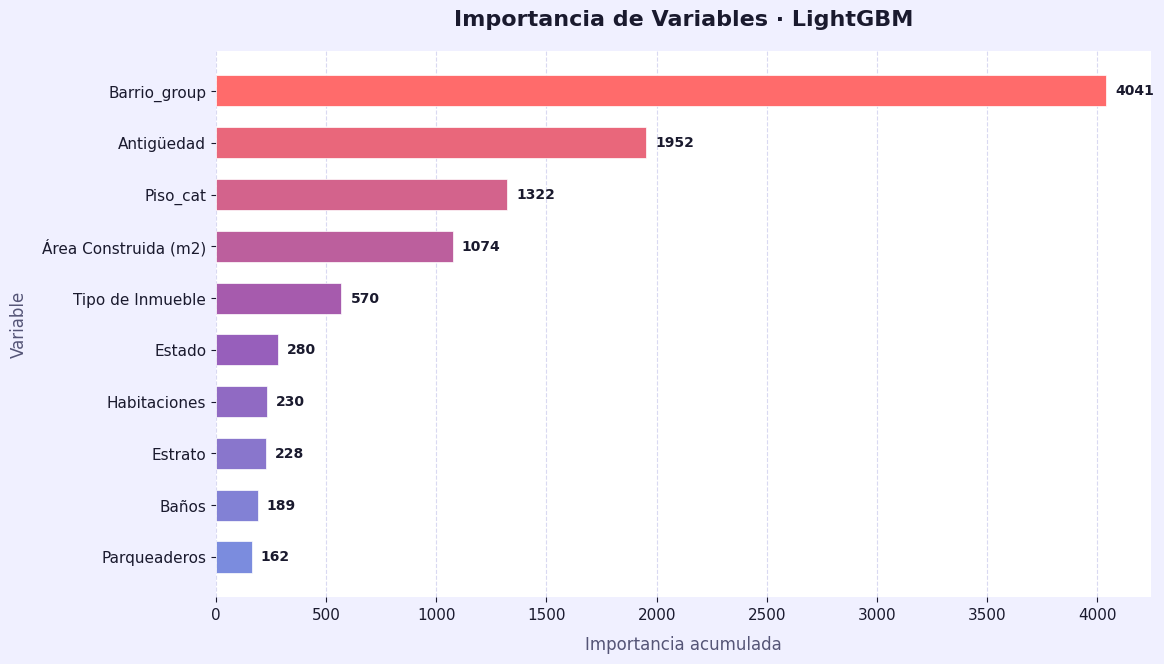

💾 Gráfico guardado como importancia_variables.png


In [41]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from sklearn.compose import TransformedTargetRegressor
from matplotlib.colors import LinearSegmentedColormap

# ── 1. Cargar el pipeline desde el .pkl ────────────────────────────────
pipeline_best = joblib.load("../models/best_lgbm_pipeline.pkl")
print("✅ Modelo cargado correctamente")
print(f"   Tipo: {type(pipeline_best)}")
print(f"   Pasos: {[s[0] for s in pipeline_best.steps]}")

# ── 2. Extraer importancias ─────────────────────────────────────────────
regressor_best = pipeline_best.named_steps["model"]
if isinstance(regressor_best, TransformedTargetRegressor):
    regressor_best = regressor_best.regressor_

if hasattr(regressor_best, "feature_importances_"):
    importances = regressor_best.feature_importances_
elif hasattr(regressor_best, "coef_"):
    importances = np.abs(regressor_best.coef_)
else:
    raise ValueError("Este modelo no tiene atributo de importancia compatible.")

# ── 3. Agrupar por variable original ───────────────────────────────────
raw_feature_names = pipeline_best.named_steps["preprocessor"].get_feature_names_out()

def get_original_feature(name):
    name = re.sub(r"^(num__|cat__|remainder__)", "", name)
    for col in numeric_features + categorical_features:
        if name == col or name.startswith(col + "_"):
            return col
    return name

importances_raw = pd.Series(importances, index=raw_feature_names)
importances_grouped = (
    importances_raw
    .groupby(importances_raw.index.map(get_original_feature))
    .sum()
    .sort_values(ascending=True)
)

print("\n📊 Importancias por variable:")
print(importances_grouped.sort_values(ascending=False).to_string())

# ── 4. Gráfico paleta RentaAI ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#F0F0FF")
ax.set_facecolor("#FFFFFF")

n = len(importances_grouped)
cmap_rentaai = LinearSegmentedColormap.from_list(
    "rentaai", ["#7B8CDE", "#9B59B6", "#FF6B6B"]
)
palette = cmap_rentaai(np.linspace(0, 1, n))

bars = ax.barh(
    importances_grouped.index,
    importances_grouped.values,
    color=palette,
    edgecolor="white",
    linewidth=0.5,
    height=0.6,
)

for bar, val in zip(bars, importances_grouped.values):
    ax.text(
        bar.get_width() + max(importances_grouped.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f}",
        va="center",
        ha="left",
        color="#1a1a2e",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title(
    "Importancia de Variables · LightGBM",
    color="#1a1a2e", fontsize=16, fontweight="bold", pad=18,
)
ax.set_xlabel("Importancia acumulada", color="#555577", fontsize=12, labelpad=10)
ax.set_ylabel("Variable", color="#555577", fontsize=12, labelpad=10)
ax.tick_params(colors="#1a1a2e", labelsize=11)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis="x", color="#D0D0EE", linewidth=0.8, linestyle="--", alpha=0.8)
ax.set_axisbelow(True)

fig.tight_layout(pad=2)
plt.savefig(
    "importancia_variables.png",
    dpi=180,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.show()
print("💾 Gráfico guardado como importancia_variables.png")

## Interpretación: Importancia de Variables — LightGBM

El gráfico muestra la **importancia acumulada** de cada variable en el modelo LightGBM,
medida como el número de veces que esa variable fue utilizada para realizar un *split*
a lo largo de todos los árboles entrenados. A mayor valor, mayor influencia en las
predicciones del modelo.

---

### Lectura por variable

| Variable | Importancia | Interpretación |
|---|---|---|
| **Barrio_group** | 4041 | Variable dominante. La ubicación es el factor más determinante del precio. |
| **Antigüedad** | 1952 | La edad del inmueble afecta significativamente el valor, capturando depreciación y renovaciones. |
| **Piso_cat** | 1322 | El piso incide en el precio, asociado a vista, privacidad y exclusividad. |
| **Área Construida (m2)** | 1074 | El tamaño importa, pero menos que la ubicación — el mercado está más segmentado por zona. |
| **Tipo de Inmueble** | 570 | Influencia moderada según si es apartamento, casa, oficina, etc. |
| **Estado** | 280 | El estado de conservación tiene un peso relevante; inmuebles nuevos o remodelados se valoran más. |
| **Habitaciones** | 230 | Menor impacto del esperado; la ubicación opaca su efecto. |
| **Estrato** | 228 | Aporta información pero correlacionada con `Barrio_group`, por lo que su peso es menor. |
| **Baños** | 189 | Contribución baja; complementa pero no determina el precio. |
| **Parqueaderos** | 162 | Variable de menor peso relativo en el conjunto. |

---

### Conclusión

> El modelo aprendió que **dónde está el inmueble y qué tan nuevo es** explican
> la mayor parte del precio, por encima de características físicas como el tamaño
> o el número de habitaciones. Esto es consistente con el mercado inmobiliario
> en ciudades como Medellín, donde el barrio y el estrato son determinantes
> históricos del valor de una propiedad.

La gran brecha entre `Barrio_group` (4041) y el resto de variables refuerza
que cualquier modelo predictivo de precios inmobiliarios en este contexto
debe capturar bien la **granularidad geográfica** para ser preciso.

2026/05/26 16:15:38 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '489307d292344ac5a867374b9c444c40', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/26 16:15:39 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handl

Mejor experimento: proyecto2-lightgbm-optuna
Run id: 702c2be3a02f4007a5dcf44daf8ab4b4
Validación RMSE: 1703047.4234547934


c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Zenbook\Documents\Aprendizaje_nube\Proyecto2_ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


🏃 View run unleashed-stag-318 at: http://127.0.0.1:5001/#/experiments/3/runs/489307d292344ac5a867374b9c444c40
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


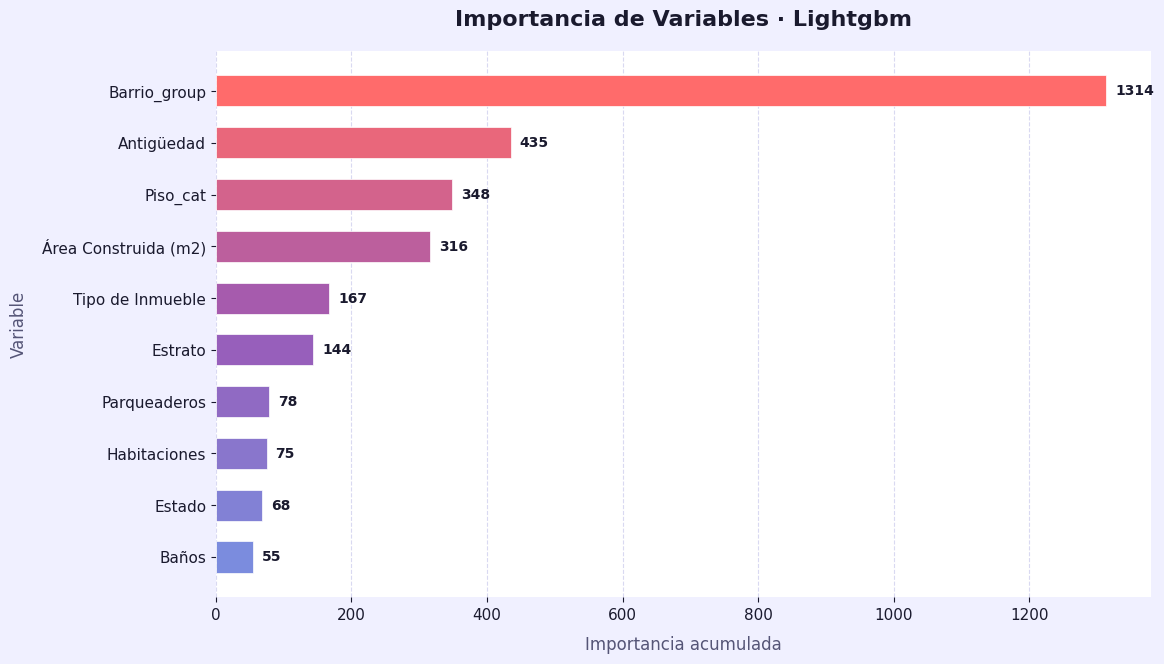

Gráfico guardado como importancia_variables.png


In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import re
# from mlflow.tracking import MlflowClient

# mlflow.set_tracking_uri("http://127.0.0.1:5001")
# client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())

# experimentos = [
#     "proyecto2-random-forest-optuna",
#     "proyecto2-lightgbm-optuna",
# ]

# mejor_info = []
# for nombre in experimentos:
#     exp = client.get_experiment_by_name(nombre)
#     if exp is None:
#         continue
#     runs = client.search_runs(
#         experiment_ids=[exp.experiment_id],
#         filter_string="attributes.status = 'FINISHED'",
#         order_by=["metrics.val_rmse ASC"],
#         max_results=1,
#     )
#     if not runs:
#         continue
#     run = runs[0]
#     mejor_info.append({
#         "experiment": nombre,
#         "run_id": run.info.run_id,
#         "val_rmse": run.data.metrics.get("val_rmse"),
#         "params": dict(run.data.params),
#         "model_family": run.data.tags.get("model_family"),
#     })

# mejor_info = sorted(mejor_info, key=lambda x: x["val_rmse"])

# if not mejor_info:
#     raise ValueError("No se encontró ningún experimento de Optuna con runs completados.")

# best_run = mejor_info[0]
# print("Mejor experimento:", best_run["experiment"])
# print("Run id:", best_run["run_id"])
# print("Validación RMSE:", best_run["val_rmse"])


# def parse_mlflow_param(value):
#     if value is None:
#         return None
#     if isinstance(value, str):
#         val = value.strip()
#         if val == "None":
#             return None
#         val = re.sub(r"[(),\s]", "", val)
#         if not val:
#             return None
#         if val.lower() in {"true", "false"}:
#             return val.lower() == "true"
#         for cast in (int, float):
#             try:
#                 return cast(val)
#             except ValueError:
#                 continue
#         return val
#     return value


# params = {}
# for k, v in best_run["params"].items():
#     parsed = parse_mlflow_param(v)
#     if parsed is not None:
#         params[k] = parsed

# model_family = best_run["model_family"]

# if model_family == "random_forest":
#     params["random_state"] = 42
#     params["n_jobs"] = -1
#     model = RandomForestRegressor(**params)
# elif model_family == "lightgbm":
#     params.pop("verbosity", None)
#     params.pop("verbose", None)
#     params["random_state"] = 42
#     model = LGBMRegressor(**params, verbosity=-1)
# else:
#     raise ValueError(f"Modelo no soportado para importancias: {model_family}")

# pipeline_best = Pipeline(
#     steps=[
#         ("preprocessor", tree_preprocessor),
#         ("model", TransformedTargetRegressor(
#             regressor=model,
#             transformer=PowerTransformer(method="yeo-johnson")
#         ))
#     ]
# )

# pipeline_best.fit(X_train, y_train)

# regressor_best = pipeline_best.named_steps["model"]
# if isinstance(regressor_best, TransformedTargetRegressor):
#     regressor_best = regressor_best.regressor_

# if hasattr(regressor_best, "feature_importances_"):
#     importances = regressor_best.feature_importances_
# elif hasattr(regressor_best, "coef_"):
#     importances = np.abs(regressor_best.coef_)
# else:
#     raise ValueError("Este modelo no tiene un atributo de importancia de variables compatible.")

# # ── Agrupar importancias por variable original ──────────────────────────
# raw_feature_names = pipeline_best.named_steps["preprocessor"].get_feature_names_out()

# def get_original_feature(name):
#     name = re.sub(r"^(num__|cat__|remainder__)", "", name)
#     for col in numeric_features + categorical_features:
#         if name == col or name.startswith(col + "_"):
#             return col
#     return name

# importances_raw = pd.Series(importances, index=raw_feature_names)
# importances_grouped = (
#     importances_raw
#     .groupby(importances_raw.index.map(get_original_feature))
#     .sum()
#     .sort_values(ascending=True)
# )

# # ── Gráfico estilizado — paleta RentaAI ────────────────────────────────
# fig, ax = plt.subplots(figsize=(12, 7))
# fig.patch.set_facecolor("#F0F0FF")      # fondo lavanda claro de la PPT
# ax.set_facecolor("#FFFFFF")             # área del gráfico blanca

# n = len(importances_grouped)

# # Degradado de la paleta RentaAI: azul lavanda → púrpura → coral
# rentaai_colors = [
#     "#7B8CDE",  # azul lavanda
#     "#8E7FD4",
#     "#9B72CB",
#     "#A865C2",
#     "#B558B9",
#     "#C24BAF",
#     "#CF3EA6",
#     "#D9459D",
#     "#E84D8A",
#     "#FF6B6B",  # coral
# ]
# # Interpolar si hay más o menos variables
# import numpy as np
# from matplotlib.colors import LinearSegmentedColormap
# cmap_rentaai = LinearSegmentedColormap.from_list("rentaai", ["#7B8CDE", "#9B59B6", "#FF6B6B"])
# palette = cmap_rentaai(np.linspace(0, 1, n))

# bars = ax.barh(
#     importances_grouped.index,
#     importances_grouped.values,
#     color=palette,
#     edgecolor="white",
#     linewidth=0.5,
#     height=0.6,
# )

# # Valor al final de cada barra
# for bar, val in zip(bars, importances_grouped.values):
#     ax.text(
#         bar.get_width() + max(importances_grouped.values) * 0.01,
#         bar.get_y() + bar.get_height() / 2,
#         f"{val:.0f}",
#         va="center",
#         ha="left",
#         color="#1a1a2e",
#         fontsize=10,
#         fontweight="bold",
#     )

# # Títulos y ejes
# ax.set_title(
#     f"Importancia de Variables · {model_family.replace('_', ' ').title()}",
#     color="#1a1a2e", fontsize=16, fontweight="bold", pad=18,
#     fontfamily="sans-serif"
# )
# ax.set_xlabel("Importancia acumulada", color="#555577", fontsize=12, labelpad=10)
# ax.set_ylabel("Variable", color="#555577", fontsize=12, labelpad=10)

# ax.tick_params(colors="#1a1a2e", labelsize=11)
# for spine in ax.spines.values():
#     spine.set_visible(False)

# ax.grid(axis="x", color="#D0D0EE", linewidth=0.8, linestyle="--", alpha=0.8)
# ax.set_axisbelow(True)

# # Fondo redondeado simulado con un rectángulo suave
# fig.tight_layout(pad=2)
# plt.savefig(
#     "importancia_variables.png",
#     dpi=180,
#     bbox_inches="tight",
#     facecolor=fig.get_facecolor()
# )
# plt.show()
# print("Gráfico guardado como importancia_variables.png")

## Interpretación: Importancia de Variables — LightGBM

El gráfico muestra la **importancia acumulada** de cada variable en el modelo LightGBM,
medida como el número de veces que esa variable fue utilizada para realizar un *split*
a lo largo de todos los árboles entrenados. A mayor valor, mayor influencia en las
predicciones del modelo.

---

### Lectura por variable

| Variable | Importancia | Interpretación |
|---|---|---|
| **Barrio_group** | 1261 | Variable dominante. La ubicación es el factor más determinante del precio. |
| **Antigüedad** | 454 | La edad del inmueble afecta significativamente el valor, capturando depreciación y renovaciones. |
| **Piso_cat** | 375 | El piso incide en el precio, asociado a vista, privacidad y exclusividad. |
| **Área Construida (m2)** | 323 | El tamaño importa, pero menos que la ubicación — el mercado está más segmentado por zona. |
| **Tipo de Inmueble** | 173 | Influencia moderada según si es apartamento, casa, oficina, etc. |
| **Estrato** | 146 | Aporta información pero correlacionada con `Barrio_group`, por lo que su peso es menor. |
| **Parqueaderos** | 77 | Contribución baja; complementa pero no determina el precio. |
| **Estado** | 71 | El estado de conservación tiene peso marginal en el modelo. |
| **Habitaciones** | 64 | Menor impacto del esperado; la ubicación opaca su efecto. |
| **Baños** | 56 | Variable de menor peso relativo en el conjunto. |

---

### Conclusión

> El modelo aprendió que **dónde está el inmueble y qué tan nuevo es** explican
> la mayor parte del precio, por encima de características físicas como el tamaño
> o el número de habitaciones. Esto es consistente con el mercado inmobiliario
> en ciudades como Medellín, donde el barrio y el estrato son determinantes
> históricos del valor de una propiedad.

La gran brecha entre `Barrio_group` (1261) y el resto de variables refuerza
que cualquier modelo predictivo de precios inmobiliarios en este contexto
debe capturar bien la **granularidad geográfica** para ser preciso.